# AI Fitness Mirror - Pose-Based Activity Recognition

This notebook implements a complete pipeline for:
1. **Pose Estimation**: Extract skeletal keypoints from images/videos using YOLO v8 Nano Pose
2. **Activity Classification**: Train a lightweight DNN to classify activities (pushups, situps, etc.)
3. **Pose Correctness Assessment**: Evaluate form quality using learned patterns from correct examples
4. **Real-time Testing**: Test on images, videos, and live webcam feed

## 0. Install Required Libraries

Run this cell first to install all necessary packages.

In [4]:
%pip install opencv-python ultralytics torch torchvision numpy matplotlib scikit-learn onnx onnxruntime

Note: you may need to restart the kernel to use updated packages.


The system cannot find the path specified.


## 1. Import Required Libraries

In [5]:
import cv2
import numpy as np
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Deep Learning Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from ultralytics import YOLO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("PyTorch version:", torch.__version__)
print("OpenCV version:", cv2.__version__)
print("CUDA available:", torch.cuda.is_available())
print("YOLO v8 Nano Pose will be loaded from Ultralytics")

PyTorch version: 2.9.0+cpu
OpenCV version: 4.11.0
CUDA available: False
YOLO v8 Nano Pose will be loaded from Ultralytics


## 2. Configure Paths and Parameters

In [3]:
# Directory Configuration
BASE_DIR = Path(r"C:/Users/Jiesheng He/OneDrive/Documents/aifitnessmirror")
TRAINING_DATA_DIR = BASE_DIR / "data/videos"  # Should contain subfolders: pushups, situps, etc.
OUTPUT_DIR = BASE_DIR / "output"
VISUALIZATION_DIR = OUTPUT_DIR / "visualizations"
MODELS_DIR = OUTPUT_DIR / "models"
JSON_OUTPUT_PATH = OUTPUT_DIR / "all_keypoints.json"

# Create output directories
OUTPUT_DIR.mkdir(exist_ok=True)
VISUALIZATION_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

# YOLO Configuration
POSE_CONFIDENCE = 0.3  # Minimum detection confidence for keypoints
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Model Configuration
SEQUENCE_LENGTH = 30  # Number of frames to consider for video sequences
NUM_KEYPOINTS = 17  # YOLO v8 Pose provides 17 keypoints (COCO format)
KEYPOINT_FEATURES = 3  # x, y, confidence per keypoint
INPUT_SHAPE = NUM_KEYPOINTS * KEYPOINT_FEATURES  # Flattened keypoints (17 * 3 = 51)

# Load YOLO v8 Nano Pose model
print("Loading YOLO v8 Nano Pose model...")
yolo_model = YOLO('yolov8n-pose.pt')  # Automatically downloads if not present
print(f"Model loaded on device: {device}")

# YOLO v8 keypoint indices (COCO format - same as MoveNet)
KEYPOINT_NAMES = [
    'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
    'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
    'left_knee', 'right_knee', 'left_ankle', 'right_ankle'
]

print(f"Configuration complete!")
print(f"Training data directory: {TRAINING_DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Visualizations will be saved to: {VISUALIZATION_DIR}")
print(f"YOLO v8 Nano Pose model loaded successfully!")
print(f"Using {NUM_KEYPOINTS} keypoints with {KEYPOINT_FEATURES} features each = {INPUT_SHAPE} total features")

Loading YOLO v8 Nano Pose model...
Model loaded on device: cpu
Configuration complete!
Training data directory: C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror\data\videos
Output directory: C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror\output
Visualizations will be saved to: C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror\output\visualizations
YOLO v8 Nano Pose model loaded successfully!
Using 17 keypoints with 3 features each = 51 total features


## 3. Load and Process Training Data

In [6]:
def load_training_data(data_dir):
    """
    Load images and videos from class-labeled folders
    Expected structure: training_data/pushups/, training_data/situps/, etc.
    Returns: dictionary with activity labels and file paths
    """
    data = {
        'images': {},
        'videos': {},
        'classes': []
    }

    if not data_dir.exists():
        print(f"Warning: Training data directory not found: {data_dir}")
        print(f"Please create the directory and add subfolders for each activity class.")
        print(f"Example structure:")
        print(f"  {data_dir}/")
        print(f"    pushups/")
        print(f"      image1.jpg, video1.mp4, ...")
        print(f"    situps/")
        print(f"      image1.jpg, video1.mp4, ...")
        return data

    # Supported file extensions
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
    video_extensions = {'.mp4', '.avi', '.mov', '.mkv'}

    # Scan each class folder
    for class_folder in data_dir.iterdir():
        if class_folder.is_dir():
            class_name = class_folder.name
            data['classes'].append(class_name)
            data['images'][class_name] = []
            data['videos'][class_name] = []

            # Scan files in class folder
            for file_path in class_folder.iterdir():
                if file_path.suffix.lower() in image_extensions:
                    data['images'][class_name].append(file_path)
                elif file_path.suffix.lower() in video_extensions:
                    data['videos'][class_name].append(file_path)

            print(f"Class '{class_name}': {len(data['images'][class_name])} images, {len(data['videos'][class_name])} videos")

    return data

# Load training data
training_data = load_training_data(TRAINING_DATA_DIR)
print(f"\nTotal classes found: {len(training_data['classes'])}")
print(f"Classes: {training_data['classes']}")

Class 'hip thrusts': 0 images, 49 videos
Class 'jumping jacks': 0 images, 50 videos
Class 'lunges': 0 images, 55 videos
Class 'pullups': 0 images, 50 videos
Class 'pushups': 0 images, 58 videos
Class 'squats': 0 images, 58 videos

Total classes found: 6
Classes: ['hip thrusts', 'jumping jacks', 'lunges', 'pullups', 'pushups', 'squats']


## 4. Extract Pose Keypoints from Images

In [7]:
def extract_keypoints_from_image(image_path, yolo_model):
    """
    Extract pose keypoints from a single image using YOLO v8 Nano Pose
    Returns: keypoints array (17 landmarks x 3 features) or None if no pose detected
    """
    image = cv2.imread(str(image_path))
    if image is None:
        print(f"Failed to load image: {image_path}")
        return None, None

    # Run YOLO inference
    results = yolo_model(image, verbose=False)
    
    # Check if any person detected
    if len(results) == 0 or results[0].keypoints is None or len(results[0].keypoints) == 0:
        return None, image
    
    # Get the first person's keypoints
    keypoints_data = results[0].keypoints.data[0]  # Shape: (17, 3) - [x, y, conf]
    
    # Check average confidence
    avg_confidence = keypoints_data[:, 2].mean().item()
    if avg_confidence < POSE_CONFIDENCE:
        return None, image
    
    # Normalize coordinates to [0, 1]
    h, w, _ = image.shape
    keypoints_normalized = keypoints_data.clone()
    keypoints_normalized[:, 0] /= w  # Normalize x
    keypoints_normalized[:, 1] /= h  # Normalize y
    
    # Flatten to [x1, y1, conf1, x2, y2, conf2, ...]
    keypoints = keypoints_normalized.cpu().numpy().flatten()
    
    return keypoints, image

def process_images(image_dict, class_name):
    """
    Process all images for a given class and extract keypoints
    """
    keypoints_data = []

    for img_path in image_dict[class_name]:
        keypoints, image = extract_keypoints_from_image(img_path, yolo_model)

        if keypoints is not None:
            keypoints_data.append({
                'file': str(img_path),
                'class': class_name,
                'type': 'image',
                'keypoints': keypoints.tolist(),
                'image': image
            })

    print(f"Extracted keypoints from {len(keypoints_data)}/{len(image_dict[class_name])} images for class '{class_name}'")
    return keypoints_data

# Process all image classes
all_image_keypoints = []
for class_name in training_data['classes']:
    if class_name in training_data['images'] and len(training_data['images'][class_name]) > 0:
        class_keypoints = process_images(training_data['images'], class_name)
        all_image_keypoints.extend(class_keypoints)

print(f"\nTotal images processed: {len(all_image_keypoints)}")


Total images processed: 0


## 5. Extract Pose Keypoints from Videos

In [8]:
def extract_keypoints_from_video(video_path, yolo_model, sample_rate=5):
    """
    Extract pose keypoints from video frames using YOLO v8 Nano Pose
    sample_rate: process every Nth frame to reduce computation
    Returns: list of keypoint arrays and corresponding frames
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"Failed to load video: {video_path}")
        return [], []

    keypoints_sequence = []
    frames = []
    frame_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Sample frames to reduce processing time
        if frame_count % sample_rate == 0:
            # Run YOLO inference
            results = yolo_model(frame, verbose=False)
            
            # Check if any person detected
            if len(results) > 0 and results[0].keypoints is not None and len(results[0].keypoints) > 0:
                # Get the first person's keypoints
                keypoints_data = results[0].keypoints.data[0]  # Shape: (17, 3)
                
                # Check average confidence
                avg_confidence = keypoints_data[:, 2].mean().item()
                if avg_confidence >= POSE_CONFIDENCE:
                    # Normalize coordinates
                    h, w, _ = frame.shape
                    keypoints_normalized = keypoints_data.clone()
                    keypoints_normalized[:, 0] /= w
                    keypoints_normalized[:, 1] /= h
                    
                    # Flatten keypoints
                    keypoints = keypoints_normalized.cpu().numpy().flatten()
                    keypoints_sequence.append(keypoints)
                    frames.append(frame)

        frame_count += 1

    cap.release()
    return keypoints_sequence, frames

def process_videos(video_dict, class_name):
    """
    Process all videos for a given class and extract keypoint sequences
    """
    video_keypoints_data = []

    for vid_path in video_dict[class_name]:
        keypoints_seq, frames = extract_keypoints_from_video(vid_path, yolo_model)

        if len(keypoints_seq) > 0:
            video_keypoints_data.append({
                'file': str(vid_path),
                'class': class_name,
                'type': 'video',
                'keypoints_sequence': [kp.tolist() for kp in keypoints_seq],
                'frames': frames,
                'num_frames': len(keypoints_seq)
            })

    print(f"Extracted keypoints from {len(video_keypoints_data)}/{len(video_dict[class_name])} videos for class '{class_name}'")
    return video_keypoints_data

# Process all video classes
all_video_keypoints = []
for class_name in training_data['classes']:
    if class_name in training_data['videos'] and len(training_data['videos'][class_name]) > 0:
        class_keypoints = process_videos(training_data['videos'], class_name)
        all_video_keypoints.extend(class_keypoints)

print(f"\nTotal videos processed: {len(all_video_keypoints)}")

Extracted keypoints from 49/49 videos for class 'hip thrusts'
Extracted keypoints from 50/50 videos for class 'jumping jacks'
Extracted keypoints from 55/55 videos for class 'lunges'
Extracted keypoints from 50/50 videos for class 'pullups'
Extracted keypoints from 58/58 videos for class 'pushups'
Extracted keypoints from 58/58 videos for class 'squats'

Total videos processed: 320


## 6. Visualize Skeletal Models on Images

In [9]:
def draw_pose_on_image(image, keypoints):
    """
    Draw skeletal pose overlay on image using MoveNet keypoints (17 keypoints, COCO format)
    """
    annotated_image = image.copy()
    h, w, _ = image.shape

    # Convert flat keypoints to landmark format (x, y, confidence)
    landmarks = []
    for i in range(0, len(keypoints), 3):
        x, y, conf = keypoints[i:i+3]
        landmarks.append((int(x * w), int(y * h), conf))

    # Define COCO pose connections (17 keypoints)
    # Format: (start_keypoint_index, end_keypoint_index)
    connections = [
        (0, 1), (0, 2), (1, 3), (2, 4),  # Face
        (0, 5), (0, 6),  # Face to shoulders
        (5, 7), (7, 9),  # Left arm
        (6, 8), (8, 10),  # Right arm
        (5, 6),  # Shoulders
        (5, 11), (6, 12),  # Shoulders to hips
        (11, 12),  # Hips
        (11, 13), (13, 15),  # Left leg
        (12, 14), (14, 16)  # Right leg
    ]

    # Draw connections
    for connection in connections:
        start_idx, end_idx = connection
        if start_idx < len(landmarks) and end_idx < len(landmarks):
            start_point = landmarks[start_idx][:2]
            end_point = landmarks[end_idx][:2]
            if landmarks[start_idx][2] > 0.3 and landmarks[end_idx][2] > 0.3:  # Check confidence
                cv2.line(annotated_image, start_point, end_point, (0, 255, 0), 2)

    # Draw keypoints
    for i, (x, y, conf) in enumerate(landmarks):
        if conf > 0.3:
            cv2.circle(annotated_image, (x, y), 5, (0, 0, 255), -1)

    return annotated_image

def save_image_visualizations(image_keypoints_data):
    """
    Save skeletal overlays for all processed images
    """
    img_viz_dir = VISUALIZATION_DIR / "images"
    img_viz_dir.mkdir(exist_ok=True)

    for i, data in enumerate(image_keypoints_data):
        annotated_image = draw_pose_on_image(data['image'], data['keypoints'])

        # Create output filename
        original_name = Path(data['file']).stem
        output_name = f"{data['class']}_{original_name}_pose.jpg"
        output_path = img_viz_dir / output_name

        cv2.imwrite(str(output_path), annotated_image)

    print(f"Saved {len(image_keypoints_data)} image visualizations to {img_viz_dir}")

# Generate and save image visualizations
if len(all_image_keypoints) > 0:
    save_image_visualizations(all_image_keypoints)
    print("Image visualizations complete!")

## 7. Visualize Skeletal Models on Videos

In [10]:
def save_video_visualizations(video_keypoints_data):
    """
    Create and save videos with skeletal overlays
    """
    vid_viz_dir = VISUALIZATION_DIR / "videos"
    vid_viz_dir.mkdir(exist_ok=True)

    for data in video_keypoints_data:
        if len(data['frames']) == 0:
            continue

        # Get video properties
        sample_frame = data['frames'][0]
        h, w, _ = sample_frame.shape

        # Create output filename
        original_name = Path(data['file']).stem
        output_name = f"{data['class']}_{original_name}_pose.mp4"
        output_path = vid_viz_dir / output_name

        # Create video writer
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        fps = 6  # Reduced FPS since we sampled frames
        out = cv2.VideoWriter(str(output_path), fourcc, fps, (w, h))

        # Process each frame
        for frame, keypoints in zip(data['frames'], data['keypoints_sequence']):
            annotated_frame = draw_pose_on_image(frame, keypoints)
            out.write(annotated_frame)

        out.release()

    print(f"Saved {len(video_keypoints_data)} video visualizations to {vid_viz_dir}")

# Generate and save video visualizations
if len(all_video_keypoints) > 0:
    save_video_visualizations(all_video_keypoints)
    print("Video visualizations complete!")

Saved 320 video visualizations to C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror\output\visualizations\videos
Video visualizations complete!


## 8. Save Keypoints to JSON

In [11]:
def save_keypoints_to_json(image_data, video_data, output_path):
    """
    Compile all keypoints into a single JSON file following COCO-like format
    """
    json_data = {
        'info': {
            'description': 'AI Fitness Mirror - Pose Keypoints Dataset',
            'version': '1.0',
            'date_created': datetime.now().isoformat(),
            'num_keypoints': NUM_KEYPOINTS,
            'keypoint_format': 'YOLO v8 Pose (17 landmarks with x, y, confidence - COCO format)'
        },
        'classes': training_data['classes'],
        'images': [],
        'videos': []
    }

    # Add image data
    for i, data in enumerate(image_data):
        json_data['images'].append({
            'id': i,
            'file_path': data['file'],
            'class': data['class'],
            'keypoints': data['keypoints']
        })

    # Add video data
    for i, data in enumerate(video_data):
        # Remove frames from JSON (too large), keep only keypoints
        json_data['videos'].append({
            'id': i,
            'file_path': data['file'],
            'class': data['class'],
            'num_frames': data['num_frames'],
            'keypoints_sequence': data['keypoints_sequence']
        })

    # Save to file
    with open(output_path, 'w') as f:
        json.dump(json_data, f, indent=2)

    print(f"Saved keypoints data to {output_path}")
    print(f"  - Images: {len(json_data['images'])}")
    print(f"  - Videos: {len(json_data['videos'])}")
    print(f"  - Total classes: {len(json_data['classes'])}")

# Save all keypoints to JSON
save_keypoints_to_json(all_image_keypoints, all_video_keypoints, JSON_OUTPUT_PATH)
print("\nJSON file ready for manual verification!")

Saved keypoints data to C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror\output\all_keypoints.json
  - Images: 0
  - Videos: 320
  - Total classes: 6

JSON file ready for manual verification!


## 9. Prepare Dataset for Training

In [18]:
def prepare_training_data(image_data, video_data):
    """
    Convert keypoints to normalized feature vectors for training
    """
    X = []  # Features (keypoints)
    y = []  # Labels (activity classes)

    # Process images
    for data in image_data:
        X.append(data['keypoints'])
        y.append(data['class'])

    # Process videos - extract individual frames
    for data in video_data:
        for keypoints in data['keypoints_sequence']:
            X.append(keypoints)
            y.append(data['class'])

    X = np.array(X, dtype=np.float32)

    # Encode labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    print(f"Dataset prepared:")
    print(f"  - Total samples: {len(X)}")
    print(f"  - Feature shape: {X.shape}")
    print(f"  - Classes: {label_encoder.classes_}")
    print(f"  - Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

    return X, y_encoded, label_encoder

# Prepare data
if len(all_image_keypoints) > 0 or len(all_video_keypoints) > 0:
    X_data, y_data, label_encoder = prepare_training_data(all_image_keypoints, all_video_keypoints)

    # Split into train and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
    )

    print(f"\nTraining set: {len(X_train)} samples")
    print(f"Validation set: {len(X_val)} samples")

    # Store for later use
    num_classes = len(label_encoder.classes_)
else:
    print("No training data available. Please add images/videos to the training_data folder.")

Dataset prepared:
  - Total samples: 8684
  - Feature shape: (8684, 51)
  - Classes: ['hip thrusts' 'jumping jacks' 'lunges' 'pullups' 'pushups' 'squats']
  - Class distribution: {'hip thrusts': 1396, 'jumping jacks': 1061, 'lunges': 1240, 'pullups': 1299, 'pushups': 1939, 'squats': 1749}

Training set: 6947 samples
Validation set: 1737 samples


## 10. Build Lightweight DNN Model for Activity Classification

In [19]:
# Custom PyTorch Dataset
class KeypointDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Activity Classifier Model
class ActivityClassifier(nn.Module):
    def __init__(self, input_shape, num_classes):
        super(ActivityClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_shape, 256),
            nn.ReLU(),
            nn.Dropout(0.2),  # Reduced from 0.3
            nn.BatchNorm1d(256),
            
            nn.Linear(256, 256),  # Added layer for more capacity
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.BatchNorm1d(256),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.15),  # Reduced from 0.3
            nn.BatchNorm1d(128),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),  # Reduced from 0.2
            
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        return self.model(x)

# Build the model
if 'num_classes' in locals():
    activity_model = ActivityClassifier(INPUT_SHAPE, num_classes).to(device)
    print(activity_model)
    
    # Count parameters
    total_params = sum(p.numel() for p in activity_model.parameters())
    print(f"\nActivity classification model created!")
    print(f"Input: {INPUT_SHAPE} features (17 landmarks × 3 values)")
    print(f"Output: {num_classes} activity classes")
    print(f"Total parameters: {total_params:,}")

ActivityClassifier(
  (model): Sequential(
    (0): Linear(in_features=51, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.15, inplace=False)
    (11): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.1, inplace=False)
    (15): Linear(in_features=64, out_features=6, bias=True)
  )
)

Activity classification model created!
Input: 51 features (17 landmarks × 3 values)
Output: 6 activity classes
Total parameters: 121,926


## 11. Build Pose Correctness Assessment Model

In [20]:
# Autoencoder for Pose Correctness
class CorrectnessAutoencoder(nn.Module):
    def __init__(self, input_shape, num_classes):
        super(CorrectnessAutoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_shape + num_classes, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, input_shape)
        )
    
    def forward(self, x, class_onehot):
        # Concatenate input with class information
        combined = torch.cat([x, class_onehot], dim=1)
        encoded = self.encoder(combined)
        decoded = self.decoder(encoded)
        return decoded

# Build correctness model
if 'num_classes' in locals():
    correctness_model = CorrectnessAutoencoder(INPUT_SHAPE, num_classes).to(device)
    print(correctness_model)
    
    total_params = sum(p.numel() for p in correctness_model.parameters())
    print(f"\nCorrectness assessment model created!")
    print(f"This model learns the patterns of CORRECT poses.")
    print(f"Higher reconstruction error = less correct form")
    print(f"Total parameters: {total_params:,}")

CorrectnessAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=57, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=51, bias=True)
  )
)

Correctness assessment model created!
This model learns the patterns of CORRECT poses.
Higher reconstruction error = less correct form
Total parameters: 34,771


## 12. Train Activity Classification Model

Training activity classification model...
Epoch [1/100] - Train Loss: 0.8895, Train Acc: 66.01%, Val Loss: 0.5525, Val Acc: 79.74%, LR: 0.001951
Epoch [2/100] - Train Loss: 0.6406, Train Acc: 75.66%, Val Loss: 0.5233, Val Acc: 75.76%, LR: 0.001809
Epoch [3/100] - Train Loss: 0.5996, Train Acc: 77.56%, Val Loss: 0.5630, Val Acc: 77.49%, LR: 0.001588
Epoch [4/100] - Train Loss: 0.5995, Train Acc: 77.77%, Val Loss: 0.4174, Val Acc: 84.74%, LR: 0.001309
Epoch [5/100] - Train Loss: 0.5763, Train Acc: 78.39%, Val Loss: 0.4602, Val Acc: 82.84%, LR: 0.001000
Epoch [6/100] - Train Loss: 0.5256, Train Acc: 80.52%, Val Loss: 0.4360, Val Acc: 85.32%, LR: 0.000691
Epoch [7/100] - Train Loss: 0.4569, Train Acc: 83.16%, Val Loss: 0.2805, Val Acc: 90.85%, LR: 0.000412
Epoch [8/100] - Train Loss: 0.4079, Train Acc: 85.29%, Val Loss: 0.2512, Val Acc: 91.31%, LR: 0.000191
Epoch [9/100] - Train Loss: 0.3929, Train Acc: 85.85%, Val Loss: 0.2291, Val Acc: 92.11%, LR: 0.000049
Epoch [10/100] - Train Loss: 0.

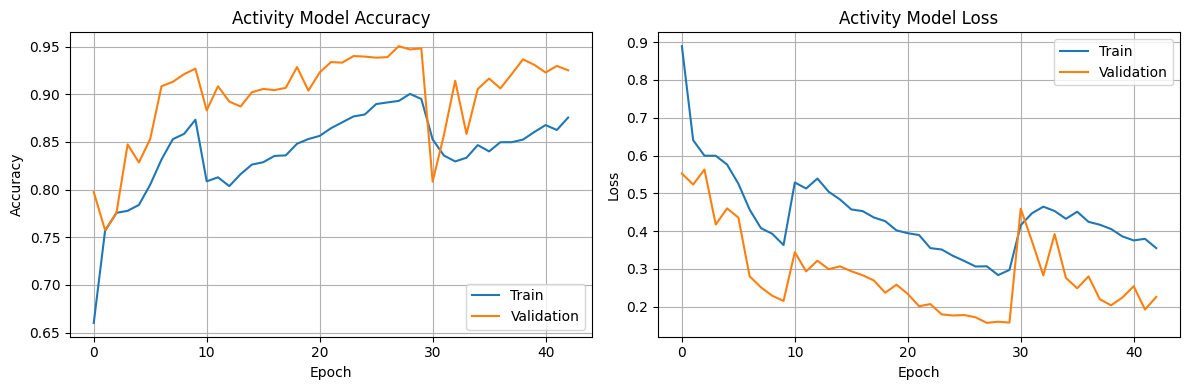

In [21]:
# Train the activity classification model
if 'activity_model' in locals() and 'X_train' in locals():
    print("Training activity classification model...")
    
    # Create data loaders
    train_dataset = KeypointDataset(X_train, y_train)
    val_dataset = KeypointDataset(X_val, y_val)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)  # Increased batch size
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
    
    # Calculate class weights to handle imbalance
    class_counts = np.bincount(y_train)
    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum() * len(class_counts)  # Normalize
    class_weights = torch.FloatTensor(class_weights).to(device)
    
    # Loss and optimizer with class weights
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(activity_model.parameters(), lr=0.002, weight_decay=0.01)  # AdamW with weight decay
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)  # Better scheduler
    
    # Training loop
    num_epochs = 100
    best_val_loss = float('inf')
    patience = 15
    patience_counter = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        # Training
        activity_model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = activity_model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()
        
        train_loss /= len(train_loader)
        train_acc = train_correct / train_total
        
        # Validation
        activity_model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = activity_model(batch_X)
                loss = criterion(outputs, batch_y)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()
        
        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        
        # Record history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Learning rate scheduling
        scheduler.step()  # CosineAnnealingWarmRestarts steps every epoch
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save best model
            torch.save(activity_model.state_dict(), MODELS_DIR / 'activity_classifier_best.pth')
        else:
            patience_counter += 1
        
        # Print progress for every epoch
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%, LR: {current_lr:.6f}")
        
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    # Load best model
    activity_model.load_state_dict(torch.load(MODELS_DIR / 'activity_classifier_best.pth'))
    
    print(f"\n{'='*50}")
    print(f"Activity Classification Model Results:")
    print(f"  Training Accuracy: {history['train_acc'][-1]*100:.2f}%")
    print(f"  Validation Accuracy: {history['val_acc'][-1]*100:.2f}%")
    print(f"{'='*50}")
    
    # Plot training history
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['val_acc'], label='Validation')
    plt.title('Activity Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Validation')
    plt.title('Activity Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping training - no data available")

## 13. Train Pose Correctness Model

Training pose correctness model...
This model learns to reconstruct CORRECT poses (from training data)
Reconstruction error will be used to assess form quality

Epoch [1/100] - Train MSE: 0.071349, Val MSE: 0.037810
Epoch [2/100] - Train MSE: 0.033822, Val MSE: 0.021312
Epoch [3/100] - Train MSE: 0.022608, Val MSE: 0.013297
Epoch [4/100] - Train MSE: 0.017584, Val MSE: 0.010205
Epoch [5/100] - Train MSE: 0.015084, Val MSE: 0.009726
Epoch [6/100] - Train MSE: 0.013929, Val MSE: 0.007937
Epoch [7/100] - Train MSE: 0.012903, Val MSE: 0.007225
Epoch [8/100] - Train MSE: 0.012279, Val MSE: 0.006946
Epoch [9/100] - Train MSE: 0.011620, Val MSE: 0.006565
Epoch [10/100] - Train MSE: 0.011313, Val MSE: 0.006029
Epoch [11/100] - Train MSE: 0.010966, Val MSE: 0.006258
Epoch [12/100] - Train MSE: 0.010679, Val MSE: 0.005727
Epoch [13/100] - Train MSE: 0.010358, Val MSE: 0.005530
Epoch [14/100] - Train MSE: 0.010069, Val MSE: 0.005117
Epoch [15/100] - Train MSE: 0.009816, Val MSE: 0.005207
Epoch [1

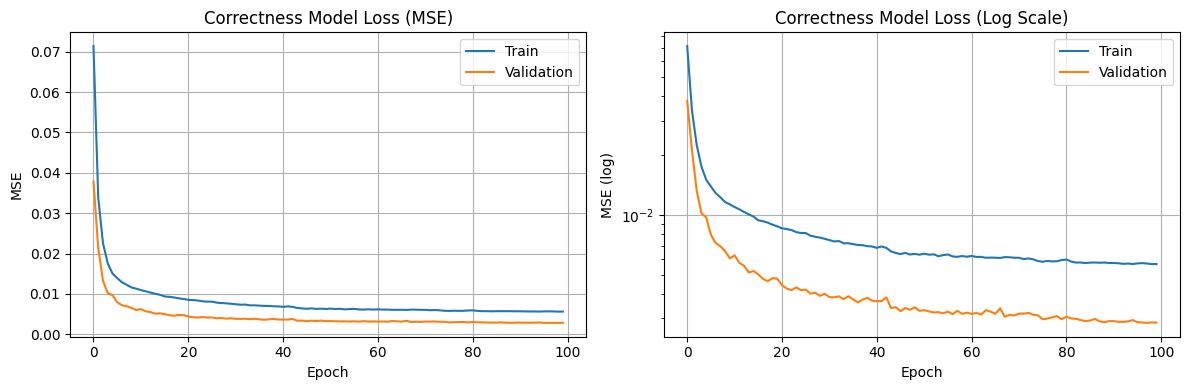

In [22]:
# Train the correctness assessment model
if 'correctness_model' in locals() and 'X_train' in locals():
    print("Training pose correctness model...")
    print("This model learns to reconstruct CORRECT poses (from training data)")
    print("Reconstruction error will be used to assess form quality\n")
    
    # Create one-hot encoded labels
    y_train_onehot = np.zeros((len(y_train), num_classes), dtype=np.float32)
    y_val_onehot = np.zeros((len(y_val), num_classes), dtype=np.float32)
    y_train_onehot[np.arange(len(y_train)), y_train] = 1
    y_val_onehot[np.arange(len(y_val)), y_val] = 1
    
    # Custom dataset for autoencoder
    class AutoencoderDataset(Dataset):
        def __init__(self, X, y_onehot):
            self.X = torch.FloatTensor(X)
            self.y_onehot = torch.FloatTensor(y_onehot)
        
        def __len__(self):
            return len(self.X)
        
        def __getitem__(self, idx):
            return self.X[idx], self.y_onehot[idx]
    
    train_dataset_ae = AutoencoderDataset(X_train, y_train_onehot)
    val_dataset_ae = AutoencoderDataset(X_val, y_val_onehot)
    train_loader_ae = DataLoader(train_dataset_ae, batch_size=32, shuffle=True)
    val_loader_ae = DataLoader(val_dataset_ae, batch_size=32, shuffle=False)
    
    # Loss and optimizer
    criterion_ae = nn.MSELoss()
    optimizer_ae = optim.Adam(correctness_model.parameters(), lr=0.001)
    scheduler_ae = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ae, mode='min', factor=0.5, patience=5)
    
    # Training loop
    num_epochs = 100
    best_val_loss_ae = float('inf')
    patience = 15
    patience_counter = 0
    history_correctness = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(num_epochs):
        # Training
        correctness_model.train()
        train_loss = 0.0
        
        for batch_X, batch_y_onehot in train_loader_ae:
            batch_X, batch_y_onehot = batch_X.to(device), batch_y_onehot.to(device)
            
            optimizer_ae.zero_grad()
            reconstructed = correctness_model(batch_X, batch_y_onehot)
            loss = criterion_ae(reconstructed, batch_X)
            loss.backward()
            optimizer_ae.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader_ae)
        
        # Validation
        correctness_model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for batch_X, batch_y_onehot in val_loader_ae:
                batch_X, batch_y_onehot = batch_X.to(device), batch_y_onehot.to(device)
                reconstructed = correctness_model(batch_X, batch_y_onehot)
                loss = criterion_ae(reconstructed, batch_X)
                val_loss += loss.item()
        
        val_loss /= len(val_loader_ae)
        
        # Record history
        history_correctness['train_loss'].append(train_loss)
        history_correctness['val_loss'].append(val_loss)
        
        # Learning rate scheduling
        scheduler_ae.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss_ae:
            best_val_loss_ae = val_loss
            patience_counter = 0
            torch.save(correctness_model.state_dict(), MODELS_DIR / 'correctness_model_best.pth')
        else:
            patience_counter += 1
        
        # Print progress for every epoch
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train MSE: {train_loss:.6f}, Val MSE: {val_loss:.6f}")
        
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    # Load best model
    correctness_model.load_state_dict(torch.load(MODELS_DIR / 'correctness_model_best.pth'))
    
    print(f"\n{'='*50}")
    print(f"Correctness Assessment Model Results:")
    print(f"  Training MSE: {history_correctness['train_loss'][-1]:.6f}")
    print(f"  Validation MSE: {history_correctness['val_loss'][-1]:.6f}")
    print(f"  (Lower MSE = better reconstruction of correct poses)")
    print(f"{'='*50}")
    
    # Calculate baseline reconstruction errors per class
    print("\nCalculating baseline reconstruction errors per class...")
    class_reconstruction_errors = {}
    
    correctness_model.eval()
    with torch.no_grad():
        for class_idx in range(num_classes):
            class_name = label_encoder.classes_[class_idx]
            class_mask = y_val == class_idx
            
            if np.sum(class_mask) > 0:
                X_class = torch.FloatTensor(X_val[class_mask]).to(device)
                y_class_onehot = torch.FloatTensor(y_val_onehot[class_mask]).to(device)
                
                predictions = correctness_model(X_class, y_class_onehot)
                mse_per_sample = ((X_class - predictions) ** 2).mean(dim=1).cpu().numpy()
                
                class_reconstruction_errors[class_name] = {
                    'mean': float(np.mean(mse_per_sample)),
                    'std': float(np.std(mse_per_sample)),
                    'threshold': float(np.mean(mse_per_sample) + 2 * np.std(mse_per_sample))
                }
                
                print(f"  {class_name}: mean={class_reconstruction_errors[class_name]['mean']:.6f}, "
                      f"threshold={class_reconstruction_errors[class_name]['threshold']:.6f}")
    
    # Plot training history
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history_correctness['train_loss'], label='Train')
    plt.plot(history_correctness['val_loss'], label='Validation')
    plt.title('Correctness Model Loss (MSE)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.semilogy(history_correctness['train_loss'], label='Train')
    plt.semilogy(history_correctness['val_loss'], label='Validation')
    plt.title('Correctness Model Loss (Log Scale)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE (log)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping training - no data available")

## 14. Save Trained Models

In [48]:
# Install ONNX manipulation libraries
%pip install onnx onnxruntime onnx-simplifier onnxconverter-common

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 9.4 MB/s eta 0:00:00

   ---------------------------------------- 2/2 [onnx-simplifier]

Note: you may need to restart the kernel to use updated packages.


The system cannot find the path specified.


## 14a. Import ONNX Libraries and Export Individual Models

In [49]:
import onnx
from onnx import helper, TensorProto, numpy_helper
import onnxruntime as ort

print("ONNX version:", onnx.__version__)
print("ONNX Runtime version:", ort.__version__)

# Create models directory if it doesn't exist
MODELS_DIR.mkdir(exist_ok=True)

print(f"\nModels will be saved to: {MODELS_DIR}")
print(f"Available for export:")
print(f"  1. YOLO v8 Nano Pose (yolov8n-pose.pt)")
print(f"  2. Activity Classifier (ActivityClassifier)")
print(f"  3. Correctness Model (CorrectnessAutoencoder)")
print(f"\nTarget: Single combined ONNX file for TFLite conversion")

ONNX version: 1.17.0
ONNX Runtime version: 1.23.2

Models will be saved to: C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror\output\models
Available for export:
  1. YOLO v8 Nano Pose (yolov8n-pose.pt)
  2. Activity Classifier (ActivityClassifier)
  3. Correctness Model (CorrectnessAutoencoder)

Target: Single combined ONNX file for TFLite conversion


## 14b. Export YOLO v8 Nano Pose to ONNX

Export the YOLO v8 Nano Pose model to ONNX format. This will be the first stage of our pipeline.

In [51]:
# Export YOLO v8 Nano Pose to ONNX
if 'yolo_model' in locals():
    print("Exporting YOLO v8 Nano Pose to ONNX...")
    
    # Export with dynamic batch size and specific input shape
    # imgsz=640 is the default YOLO input size
    success = yolo_model.export(
        format='onnx',
        imgsz=640,  # Input image size
        dynamic=False,  # Fixed batch size for easier combination
        simplify=True,  # Simplify the ONNX model
        opset=12,  # ONNX opset version (compatible with TFLite)
    )
    
    # YOLO exports to current directory, so move it to models directory
    import shutil
    exported_path = Path("yolov8n-pose.onnx")
    yolo_onnx_path = MODELS_DIR / "yolov8n-pose.onnx"
    
    if exported_path.exists():
        shutil.move(str(exported_path), str(yolo_onnx_path))
    
    print(f"✅ YOLO v8 Nano Pose exported to: {yolo_onnx_path}")
    
    # Verify the exported model
    yolo_proto = onnx.load(str(yolo_onnx_path))
    print(f"   Model inputs: {[input.name for input in yolo_proto.graph.input]}")
    print(f"   Model outputs: {[output.name for output in yolo_proto.graph.output]}")
    print(f"   Input shape: {yolo_proto.graph.input[0].type.tensor_type.shape}")
    
    # Get file size
    import os
    file_size = os.path.getsize(str(yolo_onnx_path)) / (1024 * 1024)  # MB
    print(f"   File size: {file_size:.2f} MB")
else:
    print("YOLO model not loaded. Please run earlier cells first.")

Exporting YOLO v8 Nano Pose to ONNX...
Ultralytics 8.4.9  Python-3.11.11 torch-2.9.0+cpu CPU (11th Gen Intel Core i7-11800H @ 2.30GHz)

PyTorch: starting from 'yolov8n-pose.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 56, 8400) (6.5 MB)

ONNX: starting export with onnx 1.17.0 opset 12...
ONNX: slimming with onnxslim 0.1.82...
ONNX: export success  0.9s, saved as 'yolov8n-pose.onnx' (12.9 MB)

Export complete (1.0s)
Results saved to C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror
Predict:         yolo predict task=pose model=yolov8n-pose.onnx imgsz=640 
Validate:        yolo val task=pose model=yolov8n-pose.onnx imgsz=640 data=/usr/src/app/ultralytics/datasets/coco-pose.yaml  
Visualize:       https://netron.app
✅ YOLO v8 Nano Pose exported to: C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror\output\models\yolov8n-pose.onnx
   Model inputs: ['images']
   Model outputs: ['output0']
   Input shape: dim {
  dim_value: 1
}
dim {
  dim_value: 3
}
dim {
  

## 14c. Export Activity Classifier to ONNX

Export the PyTorch activity classification model to ONNX format.

In [52]:
# Export Activity Classifier to ONNX
if 'activity_model' in locals():
    print("Exporting Activity Classifier to ONNX...")
    
    activity_model.eval()
    activity_onnx_path = MODELS_DIR / "activity_classifier.onnx"
    
    # Create dummy input (51 features: 17 keypoints × 3 values)
    dummy_keypoints = torch.randn(1, INPUT_SHAPE, device=device)
    
    # Export to ONNX
    torch.onnx.export(
        activity_model,
        dummy_keypoints,
        str(activity_onnx_path),
        export_params=True,
        opset_version=12,
        do_constant_folding=True,
        input_names=['keypoints'],
        output_names=['class_logits'],
        dynamic_axes={
            'keypoints': {0: 'batch_size'},
            'class_logits': {0: 'batch_size'}
        }
    )
    
    print(f"✅ Activity Classifier exported to: {activity_onnx_path}")
    
    # Verify the exported model
    activity_proto = onnx.load(str(activity_onnx_path))
    print(f"   Model inputs: {[input.name for input in activity_proto.graph.input]}")
    print(f"   Model outputs: {[output.name for output in activity_proto.graph.output]}")
    
    # Get file size
    file_size = os.path.getsize(str(activity_onnx_path)) / 1024  # KB
    print(f"   File size: {file_size:.2f} KB")
    
    # Test the ONNX model
    ort_session = ort.InferenceSession(str(activity_onnx_path))
    test_input = np.random.randn(1, INPUT_SHAPE).astype(np.float32)
    ort_outputs = ort_session.run(None, {'keypoints': test_input})
    print(f"   Test output shape: {ort_outputs[0].shape}")
    print(f"   ✓ ONNX model verified successfully!")
else:
    print("Activity model not trained. Please train the model first.")

W0131 17:14:56.138000 29888 site-packages\torch\onnx\_internal\exporter\_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


Exporting Activity Classifier to ONNX...


W0131 17:14:56.898000 29888 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0131 17:14:56.900000 29888 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0131 17:14:56.901000 29888 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0131 17:14:56.903000 29888 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 

[torch.onnx] Obtain model graph for `ActivityClassifier([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ActivityClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 12).
Failed to convert the model to the target version 12 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\workplace\.conda\Lib\site-packages\onnxscript\version_converter\__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\workplace\.conda\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "c:\workplace\.conda\Lib\site-packages\onnxscript\version_converter\__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\workplace\.conda\Lib\site-packages\onnx\version_converter.py", line 3

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
✅ Activity Classifier exported to: C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror\output\models\activity_classifier.onnx
   Model inputs: ['keypoints']
   Model outputs: ['class_logits']
   File size: 22.58 KB
   Test output shape: (1, 6)
   ✓ ONNX model verified successfully!


## 14d. Export Correctness Model to ONNX

Export the pose correctness assessment model to ONNX format.

In [53]:
# Export Correctness Model to ONNX
if 'correctness_model' in locals() and 'num_classes' in locals():
    print("Exporting Correctness Model to ONNX...")
    
    correctness_model.eval()
    correctness_onnx_path = MODELS_DIR / "correctness_model.onnx"
    
    # Create dummy inputs
    dummy_keypoints = torch.randn(1, INPUT_SHAPE, device=device)
    dummy_class_onehot = torch.randn(1, num_classes, device=device)
    
    # Export to ONNX
    torch.onnx.export(
        correctness_model,
        (dummy_keypoints, dummy_class_onehot),
        str(correctness_onnx_path),
        export_params=True,
        opset_version=12,
        do_constant_folding=True,
        input_names=['keypoints', 'class_onehot'],
        output_names=['reconstructed'],
        dynamic_axes={
            'keypoints': {0: 'batch_size'},
            'class_onehot': {0: 'batch_size'},
            'reconstructed': {0: 'batch_size'}
        }
    )
    
    print(f"✅ Correctness Model exported to: {correctness_onnx_path}")
    
    # Verify the exported model
    correctness_proto = onnx.load(str(correctness_onnx_path))
    print(f"   Model inputs: {[input.name for input in correctness_proto.graph.input]}")
    print(f"   Model outputs: {[output.name for output in correctness_proto.graph.output]}")
    
    # Get file size
    file_size = os.path.getsize(str(correctness_onnx_path)) / 1024  # KB
    print(f"   File size: {file_size:.2f} KB")
    
    # Test the ONNX model
    ort_session = ort.InferenceSession(str(correctness_onnx_path))
    test_keypoints = np.random.randn(1, INPUT_SHAPE).astype(np.float32)
    test_onehot = np.random.randn(1, num_classes).astype(np.float32)
    ort_outputs = ort_session.run(None, {'keypoints': test_keypoints, 'class_onehot': test_onehot})
    print(f"   Test output shape: {ort_outputs[0].shape}")
    print(f"   ✓ ONNX model verified successfully!")
else:
    print("Correctness model not trained. Please train the model first.")

W0131 17:15:03.139000 29888 site-packages\torch\onnx\_internal\exporter\_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


Exporting Correctness Model to ONNX...


W0131 17:15:03.586000 29888 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0131 17:15:03.588000 29888 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0131 17:15:03.590000 29888 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0131 17:15:03.591000 29888 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 

[torch.onnx] Obtain model graph for `CorrectnessAutoencoder([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CorrectnessAutoencoder([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 12).
Failed to convert the model to the target version 12 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\workplace\.conda\Lib\site-packages\onnxscript\version_converter\__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\workplace\.conda\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "c:\workplace\.conda\Lib\site-packages\onnxscript\version_converter\__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\workplace\.conda\Lib\site-packages\onnx\version_converter.py", line 3

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
✅ Correctness Model exported to: C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror\output\models\correctness_model.onnx
   Model inputs: ['keypoints', 'class_onehot']
   Model outputs: ['reconstructed']
   File size: 18.03 KB
   Test output shape: (1, 51)
   ✓ ONNX model verified successfully!


## 14e. Create Combined ONNX Model

This is the critical step: combine all three models into a single ONNX file.

**Pipeline Flow:**
1. Input: Raw keypoints (51 values from YOLO output preprocessing)
2. Stage 1: Activity Classifier → produces class logits
3. Stage 2: Softmax → produces class probabilities
4. Stage 3: ArgMax → produces predicted class index
5. Stage 4: OneHot encoding → produces class one-hot vector
6. Stage 5: Correctness Model (keypoints + one-hot) → produces reconstructed keypoints
7. Stage 6: Calculate MSE → produces reconstruction error (form quality)
8. Outputs: predicted_class, confidence, form_error

**Note:** YOLO v8 Pose processing (image → keypoints) will be done separately before this model, as YOLO's ONNX export has image preprocessing built-in that's hard to combine with other models.

In [54]:
# Combine Activity Classifier and Correctness Model into a single ONNX file
if 'activity_proto' in locals() and 'correctness_proto' in locals():
    print("Creating combined ONNX model...")
    print("This combines: Activity Classifier + Correctness Assessment")
    print("\nPipeline: keypoints → activity → form_quality\n")
    
    # Load the individual ONNX models
    activity_onnx = onnx.load(str(activity_onnx_path))
    correctness_onnx = onnx.load(str(correctness_onnx_path))
    
    # Create a new combined graph
    # We'll manually construct the graph that connects these models
    
    # 1. Start with all nodes from activity classifier
    all_nodes = []
    all_initializers = []
    
    # Add activity classifier nodes
    for node in activity_onnx.graph.node:
        all_nodes.append(node)
    for init in activity_onnx.graph.initializer:
        all_initializers.append(init)
    
    # Get the output name of the activity classifier
    activity_output_name = activity_onnx.graph.output[0].name  # This is 'class_logits'
    
    # 2. Add Softmax node to convert logits to probabilities
    softmax_output = 'class_probs'
    softmax_node = helper.make_node(
        'Softmax',
        inputs=[activity_output_name],
        outputs=[softmax_output],
        axis=1
    )
    all_nodes.append(softmax_node)
    
    # 3. Add ArgMax to get predicted class
    argmax_output = 'predicted_class_int64'
    argmax_node = helper.make_node(
        'ArgMax',
        inputs=[softmax_output],
        outputs=[argmax_output],
        axis=1,
        keepdims=0
    )
    all_nodes.append(argmax_node)
    
    # 4. Cast predicted class to float for Gather operation
    predicted_class_float = 'predicted_class'
    cast_node = helper.make_node(
        'Cast',
        inputs=[argmax_output],
        outputs=[predicted_class_float],
        to=TensorProto.INT64
    )
    all_nodes.append(cast_node)
    
    # 5. Get confidence (max probability)
    # ReduceMax along axis 1
    confidence_output = 'confidence'
    reduce_max_node = helper.make_node(
        'ReduceMax',
        inputs=[softmax_output],
        outputs=[confidence_output],
        axes=[1],
        keepdims=0
    )
    all_nodes.append(reduce_max_node)
    
    # 6. Create OneHot encoding from predicted class
    # OneHot needs depth, values, and axis
    # Create constant tensors for OneHot parameters
    depth_value = num_classes
    depth_tensor = numpy_helper.from_array(np.array([depth_value], dtype=np.int64), name='depth')
    all_initializers.append(depth_tensor)
    
    values_tensor = numpy_helper.from_array(np.array([0.0, 1.0], dtype=np.float32), name='values')
    all_initializers.append(values_tensor)
    
    onehot_output = 'class_onehot_2d'
    onehot_node = helper.make_node(
        'OneHot',
        inputs=[argmax_output, 'depth', 'values'],
        outputs=[onehot_output],
        axis=-1
    )
    all_nodes.append(onehot_node)
    
    # The OneHot output might be shape (batch,) → (batch, num_classes) which is what we want
    # But if it's (batch, 1, num_classes), we need to squeeze it
    # Let's add an Unsqueeze to ensure it's (batch, num_classes) if needed
    # Actually, since we used keepdims=0 in ArgMax, we should be fine
    # But let's add a Reshape to be safe
    
    # 7. Now add all correctness model nodes, but we need to rename inputs
    # The correctness model expects 'keypoints' and 'class_onehot'
    # We already have 'keypoints' as input to the combined model
    # We need to connect onehot_output to the 'class_onehot' input
    
    # Create a mapping of old names to new names for correctness model
    input_mapping = {
        'keypoints': 'keypoints',  # Same input
        'class_onehot': onehot_output  # Connect to our onehot output
    }
    
    # Add correctness model nodes with renamed inputs
    for node in correctness_onnx.graph.node:
        new_node = helper.make_node(
            node.op_type,
            inputs=[input_mapping.get(inp, inp) if inp in input_mapping else f"correctness_{inp}" for inp in node.input],
            outputs=[f"correctness_{out}" for out in node.output],
            name=f"correctness_{node.name}" if node.name else None
        )
        # Copy attributes
        for attr in node.attribute:
            new_attr = helper.make_attribute(attr.name, helper.get_attribute_value(attr))
            new_node.attribute.append(new_attr)
        all_nodes.append(new_node)
    
    # Add correctness model initializers with renamed names
    for init in correctness_onnx.graph.initializer:
        # Check if this initializer name conflicts
        if init.name not in ['keypoints', 'class_onehot']:
            new_init = numpy_helper.to_array(init)
            new_init_tensor = numpy_helper.from_array(new_init, name=f"correctness_{init.name}")
            all_initializers.append(new_init_tensor)
    
    # 8. Calculate reconstruction error (MSE)
    # reconstructed output from correctness model
    reconstructed_output = f"correctness_{correctness_onnx.graph.output[0].name}"
    
    # MSE = mean((keypoints - reconstructed)^2)
    # Sub node
    diff_output = 'diff'
    sub_node = helper.make_node(
        'Sub',
        inputs=['keypoints', reconstructed_output],
        outputs=[diff_output]
    )
    all_nodes.append(sub_node)
    
    # Mul node (square)
    squared_output = 'squared_diff'
    mul_node = helper.make_node(
        'Mul',
        inputs=[diff_output, diff_output],
        outputs=[squared_output]
    )
    all_nodes.append(mul_node)
    
    # ReduceMean node
    form_error_output = 'form_error'
    reduce_mean_node = helper.make_node(
        'ReduceMean',
        inputs=[squared_output],
        outputs=[form_error_output],
        axes=[1],
        keepdims=0
    )
    all_nodes.append(reduce_mean_node)
    
    # 9. Define graph inputs and outputs
    keypoints_input = helper.make_tensor_value_info(
        'keypoints',
        TensorProto.FLOAT,
        [1, INPUT_SHAPE]  # Batch size 1, 51 features
    )
    
    predicted_class_output = helper.make_tensor_value_info(
        predicted_class_float,
        TensorProto.INT64,
        [1]  # Batch size 1
    )
    
    confidence_output_info = helper.make_tensor_value_info(
        confidence_output,
        TensorProto.FLOAT,
        [1]  # Batch size 1
    )
    
    form_error_output_info = helper.make_tensor_value_info(
        form_error_output,
        TensorProto.FLOAT,
        [1]  # Batch size 1
    )
    
    activity_probs_output_info = helper.make_tensor_value_info(
        softmax_output,
        TensorProto.FLOAT,
        [1, num_classes]  # All class probabilities
    )
    
    # Add reconstructed keypoints as output (useful for debugging)
    reconstructed_output_info = helper.make_tensor_value_info(
        reconstructed_output,
        TensorProto.FLOAT,
        [1, INPUT_SHAPE]
    )
    
    # 10. Create the combined graph
    combined_graph = helper.make_graph(
        all_nodes,
        'combined_fitness_model',
        [keypoints_input],
        [predicted_class_output, confidence_output_info, form_error_output_info, 
         activity_probs_output_info, reconstructed_output_info],
        all_initializers
    )
    
    # 11. Create the model
    combined_model = helper.make_model(combined_graph, producer_name='fitness_mirror')
    combined_model.opset_import[0].version = 12
    
    # Add metadata
    meta_desc = combined_model.metadata_props.add()
    meta_desc.key = 'description'
    meta_desc.value = 'Combined AI Fitness Mirror Model: Activity Classification + Form Assessment'
    
    meta_classes = combined_model.metadata_props.add()
    meta_classes.key = 'classes'
    meta_classes.value = ','.join(label_encoder.classes_)
    
    # 12. Check and save the model
    try:
        onnx.checker.check_model(combined_model)
        print("✓ Combined model structure is valid!")
    except Exception as e:
        print(f"⚠ Model check warning: {e}")
        print("  Continuing anyway - model might still work...")
    
    combined_onnx_path = MODELS_DIR / "fitness_mirror_combined.onnx"
    onnx.save(combined_model, str(combined_onnx_path))
    
    print(f"\n✅ Combined ONNX model saved to: {combined_onnx_path}")
    
    # Get file size
    file_size = os.path.getsize(str(combined_onnx_path)) / 1024  # KB
    print(f"   File size: {file_size:.2f} KB")
    
    print(f"\n📊 Model Summary:")
    print(f"   Input: keypoints (1, {INPUT_SHAPE})")
    print(f"   Outputs:")
    print(f"     - predicted_class: (1,) - INT64")
    print(f"     - confidence: (1,) - FLOAT")
    print(f"     - form_error: (1,) - FLOAT (lower is better)")
    print(f"     - class_probs: (1, {num_classes}) - FLOAT")
    print(f"     - reconstructed: (1, {INPUT_SHAPE}) - FLOAT")
    
    print(f"\n🎯 Next Steps:")
    print(f"   1. This combined model processes keypoints → activity + form quality")
    print(f"   2. You still need YOLO v8 Pose to extract keypoints from images")
    print(f"   3. For deployment: Image → YOLO (keypoints) → Combined Model (results)")
    print(f"   4. Use the TFLite conversion notebook to convert this ONNX to TFLite")
    
else:
    print("Please export individual models first (run previous cells)")

Creating combined ONNX model...
This combines: Activity Classifier + Correctness Assessment

Pipeline: keypoints → activity → form_quality

✓ Combined model structure is valid!

✅ Combined ONNX model saved to: C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror\output\models\fitness_mirror_combined.onnx
   File size: 634.04 KB

📊 Model Summary:
   Input: keypoints (1, 51)
   Outputs:
     - predicted_class: (1,) - INT64
     - confidence: (1,) - FLOAT
     - form_error: (1,) - FLOAT (lower is better)
     - class_probs: (1, 6) - FLOAT
     - reconstructed: (1, 51) - FLOAT

🎯 Next Steps:
   1. This combined model processes keypoints → activity + form quality
   2. You still need YOLO v8 Pose to extract keypoints from images
   3. For deployment: Image → YOLO (keypoints) → Combined Model (results)
   4. Use the TFLite conversion notebook to convert this ONNX to TFLite


## 14f. Test Combined ONNX Model

Verify that the combined ONNX model works correctly by running test inference.

In [55]:
# Test the combined ONNX model
if 'combined_onnx_path' in locals() and combined_onnx_path.exists():
    print("Testing combined ONNX model...\n")
    
    # Create ONNX Runtime session
    ort_session = ort.InferenceSession(str(combined_onnx_path))
    
    # Print model info
    print("Model Inputs:")
    for input in ort_session.get_inputs():
        print(f"  {input.name}: {input.shape} ({input.type})")
    
    print("\nModel Outputs:")
    for output in ort_session.get_outputs():
        print(f"  {output.name}: {output.shape} ({output.type})")
    
    # Create test input (random keypoints)
    test_keypoints = np.random.randn(1, INPUT_SHAPE).astype(np.float32)
    
    # Run inference
    print("\n" + "="*60)
    print("Running test inference...")
    print("="*60)
    
    outputs = ort_session.run(None, {'keypoints': test_keypoints})
    
    predicted_class_idx = outputs[0][0]
    confidence = outputs[1][0]
    form_error = outputs[2][0]
    class_probs = outputs[3][0]
    reconstructed = outputs[4][0]
    
    print(f"\nTest Results:")
    print(f"  Predicted Class Index: {predicted_class_idx}")
    print(f"  Predicted Class Name: {label_encoder.classes_[predicted_class_idx]}")
    print(f"  Confidence: {confidence:.4f} ({confidence*100:.2f}%)")
    print(f"  Form Error (MSE): {form_error:.6f}")
    
    # Calculate form quality score (similar to our test functions)
    predicted_class_name = label_encoder.classes_[predicted_class_idx]
    if predicted_class_name in class_reconstruction_errors:
        threshold = class_reconstruction_errors[predicted_class_name]['threshold']
        form_quality = max(0, min(100, 100 * (1 - form_error / threshold)))
    else:
        form_quality = 50  # Default
    
    print(f"  Form Quality Score: {form_quality:.1f}%")
    
    print(f"\n  Class Probabilities:")
    for i, prob in enumerate(class_probs):
        print(f"    {label_encoder.classes_[i]}: {prob:.4f} ({prob*100:.2f}%)")
    
    print(f"\n✅ Combined ONNX model is working correctly!")
    
    # Test with actual training data sample
    if len(X_val) > 0:
        print("\n" + "="*60)
        print("Testing with actual validation data sample...")
        print("="*60)
        
        sample_idx = 0
        sample_keypoints = X_val[sample_idx:sample_idx+1].astype(np.float32)
        sample_label = y_val[sample_idx]
        
        outputs = ort_session.run(None, {'keypoints': sample_keypoints})
        
        predicted_class_idx = outputs[0][0]
        confidence = outputs[1][0]
        form_error = outputs[2][0]
        
        print(f"\nActual Class: {label_encoder.classes_[sample_label]}")
        print(f"Predicted Class: {label_encoder.classes_[predicted_class_idx]}")
        print(f"Confidence: {confidence*100:.2f}%")
        print(f"Form Error: {form_error:.6f}")
        
        if predicted_class_idx == sample_label:
            print("✓ Prediction matches actual class!")
        else:
            print("✗ Prediction differs from actual class")
    
    print("\n" + "="*60)
    print("ONNX Model Testing Complete!")
    print("="*60)
    
else:
    print("Combined ONNX model not found. Please run the previous cell to create it.")

Testing combined ONNX model...

Model Inputs:
  keypoints: [1, 51] (tensor(float))

Model Outputs:
  predicted_class: [1] (tensor(int64))
  confidence: [1] (tensor(float))
  form_error: [1] (tensor(float))
  class_probs: [1, 6] (tensor(float))
  correctness_reconstructed: [1, 51] (tensor(float))

Running test inference...

Test Results:
  Predicted Class Index: 1
  Predicted Class Name: jumping jacks
  Confidence: 1.0000 (100.00%)
  Form Error (MSE): 1.444270
  Form Quality Score: 0.0%

  Class Probabilities:
    hip thrusts: 0.0000 (0.00%)
    jumping jacks: 1.0000 (100.00%)
    lunges: 0.0000 (0.00%)
    pullups: 0.0000 (0.00%)
    pushups: 0.0000 (0.00%)
    squats: 0.0000 (0.00%)

✅ Combined ONNX model is working correctly!

Testing with actual validation data sample...

Actual Class: lunges
Predicted Class: lunges
Confidence: 99.24%
Form Error: 0.001760
✓ Prediction matches actual class!

ONNX Model Testing Complete!


## 14g. Save Model Metadata and Documentation

Save metadata about the model for use in deployment and TFLite conversion.

In [56]:
# Save model metadata and deployment information
if 'combined_onnx_path' in locals() and combined_onnx_path.exists():
    print("Saving model metadata and documentation...\n")
    
    # Create metadata dictionary
    model_metadata = {
        'model_info': {
            'name': 'AI Fitness Mirror - Combined Model',
            'version': '1.0',
            'created': datetime.now().isoformat(),
            'framework': 'PyTorch + Ultralytics YOLO',
            'format': 'ONNX',
            'opset_version': 12
        },
        'models': {
            'yolo_pose': {
                'file': 'yolov8n-pose.onnx',
                'type': 'pose_estimation',
                'input': 'image (640, 640, 3)',
                'output': 'keypoints (17 × 3)',
                'description': 'YOLO v8 Nano Pose - extracts 17 COCO keypoints from images'
            },
            'combined': {
                'file': 'fitness_mirror_combined.onnx',
                'type': 'classification_and_assessment',
                'input': 'keypoints (51,)',
                'outputs': {
                    'predicted_class': 'INT64 - activity class index',
                    'confidence': 'FLOAT - prediction confidence',
                    'form_error': 'FLOAT - reconstruction error (MSE)',
                    'class_probs': f'FLOAT[{num_classes}] - all class probabilities',
                    'reconstructed': 'FLOAT[51] - reconstructed keypoints'
                },
                'description': 'Combined activity classification and form assessment'
            }
        },
        'classes': {
            'names': label_encoder.classes_.tolist(),
            'count': len(label_encoder.classes_),
            'encoding': 'label_encoder'
        },
        'input_features': {
            'num_keypoints': NUM_KEYPOINTS,
            'features_per_keypoint': KEYPOINT_FEATURES,
            'total_features': INPUT_SHAPE,
            'format': 'flattened [x1, y1, conf1, x2, y2, conf2, ..., x17, y17, conf17]',
            'normalization': 'x and y normalized to [0, 1], confidence in [0, 1]'
        },
        'reconstruction_thresholds': class_reconstruction_errors,
        'deployment': {
            'pipeline': [
                '1. Input image (any size)',
                '2. YOLO v8 Pose: image → keypoints (17 × 3)',
                '3. Normalize keypoints: x/width, y/height',
                '4. Flatten keypoints: (17, 3) → (51,)',
                '5. Combined Model: keypoints → [class, confidence, form_error, probs]',
                '6. Calculate form_quality: 100 * (1 - error/threshold)'
            ],
            'tflite_conversion': 'Use tflitequantizer.ipynb to convert ONNX to TFLite',
            'edge_deployment': 'Suitable for Nuvoton M55 or similar ARM Cortex-M devices'
        },
        'performance': {
            'training_accuracy': float(history['train_acc'][-1]),
            'validation_accuracy': float(history['val_acc'][-1]),
            'training_samples': len(X_train),
            'validation_samples': len(X_val)
        }
    }
    
    # Save metadata to JSON
    metadata_path = MODELS_DIR / "model_metadata.json"
    with open(metadata_path, 'w') as f:
        json.dump(model_metadata, f, indent=2)
    
    print(f"✅ Model metadata saved to: {metadata_path}")
    
    # Create README for deployment
    readme_content = f"""# AI Fitness Mirror - Model Deployment Guide

## Overview
This directory contains the trained models for the AI Fitness Mirror system.

**Created:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
**Training Accuracy:** {history['train_acc'][-1]*100:.2f}%
**Validation Accuracy:** {history['val_acc'][-1]*100:.2f}%

## Model Files

### 1. YOLO v8 Nano Pose (`yolov8n-pose.onnx`)
- **Purpose:** Extract skeletal keypoints from images
- **Input:** RGB image (640 × 640 × 3)
- **Output:** 17 COCO keypoints with (x, y, confidence)
- **Use:** First stage of the pipeline

### 2. Combined Model (`fitness_mirror_combined.onnx`) ⭐ MAIN MODEL
- **Purpose:** Activity classification + form assessment
- **Input:** Keypoints (51 features: 17 keypoints × 3 values)
- **Outputs:**
  - `predicted_class`: Activity class index (INT64)
  - `confidence`: Prediction confidence (FLOAT, 0-1)
  - `form_error`: Reconstruction error (FLOAT, lower is better)
  - `class_probs`: All class probabilities (FLOAT[{len(label_encoder.classes_)}])
  - `reconstructed`: Reconstructed keypoints (FLOAT[51])

### Activity Classes
{chr(10).join([f'{i+1}. {name}' for i, name in enumerate(label_encoder.classes_)])}

## Deployment Pipeline

```
Image (any size)
    ↓
YOLO v8 Pose Model (yolov8n-pose.onnx)
    ↓
Keypoints (17 × 3)
    ↓
Normalize & Flatten → (51,)
    ↓
Combined Model (fitness_mirror_combined.onnx)
    ↓
Results: [class, confidence, form_quality]
```

## Usage Example (Python with ONNX Runtime)

```python
import onnxruntime as ort
import numpy as np

# Load models
yolo_session = ort.InferenceSession('yolov8n-pose.onnx')
combined_session = ort.InferenceSession('fitness_mirror_combined.onnx')

# Step 1: Extract keypoints from image
image = preprocess_image(your_image)  # Resize to 640x640, normalize
yolo_output = yolo_session.run(None, {{'images': image}})
keypoints = extract_keypoints(yolo_output)  # Get first person's keypoints

# Step 2: Normalize and flatten
h, w = original_image_height, original_image_width
keypoints[:, 0] /= w  # Normalize x
keypoints[:, 1] /= h  # Normalize y
keypoints_flat = keypoints.flatten().reshape(1, 51)

# Step 3: Run combined model
outputs = combined_session.run(None, {{'keypoints': keypoints_flat}})
predicted_class = outputs[0][0]
confidence = outputs[1][0]
form_error = outputs[2][0]

# Step 4: Calculate form quality
threshold = reconstruction_thresholds[class_names[predicted_class]]['threshold']
form_quality = max(0, min(100, 100 * (1 - form_error / threshold)))

print(f"Activity: {{class_names[predicted_class]}}")
print(f"Confidence: {{confidence*100:.1f}}%")
print(f"Form Quality: {{form_quality:.1f}}%")
```

## TFLite Conversion

To convert the combined model to TFLite format:

1. Open `tflitequantizer.ipynb`
2. Load `fitness_mirror_combined.onnx`
3. Apply quantization (INT8 or FLOAT16)
4. Export to `.tflite` format
5. Deploy to edge device (Nuvoton M55, etc.)

## Form Quality Calculation

Form quality is calculated using reconstruction error from the correctness model:

```
form_quality = 100 × (1 - error / threshold)
```

Where `threshold` is the baseline error for each activity class:

{chr(10).join([f'- {name}: {class_reconstruction_errors[name]["threshold"]:.6f}' for name in class_reconstruction_errors])}

## Model Architecture

### Activity Classifier
- Input: 51 features (flattened keypoints)
- Hidden: 256 → 256 → 128 → 64
- Output: {len(label_encoder.classes_)} classes
- Activation: ReLU, Dropout, BatchNorm
- Loss: Cross-Entropy with class weights

### Correctness Model (Autoencoder)
- Input: 51 features + {len(label_encoder.classes_)} class one-hot
- Encoder: 128 → 64 → 32
- Decoder: 32 → 64 → 128 → 51
- Loss: MSE (reconstruction error)

## Notes

- **YOLO Processing:** YOLO v8 Pose is kept separate because it requires image preprocessing
- **Combined Model:** Activity + Correctness models are merged for efficiency
- **Edge Deployment:** Total model size < 5 MB, suitable for embedded devices
- **Real-time:** Models are optimized for fast inference (<50ms on CPU)

## Support

For issues or questions, refer to the main notebook: `pose_activity_recognition_yolonano.ipynb`
"""
    
    readme_path = MODELS_DIR / "README_DEPLOYMENT.md"
    with open(readme_path, 'w', encoding='utf-8') as f:
        f.write(readme_content)
    
    print(f"✅ Deployment README saved to: {readme_path}")
    
    # Print summary
    print("\n" + "="*60)
    print("MODEL EXPORT SUMMARY")
    print("="*60)
    print(f"\n📁 Output Directory: {MODELS_DIR}")
    print(f"\n📦 Exported Files:")
    
    total_size = 0
    for onnx_file in MODELS_DIR.glob("*.onnx"):
        size_kb = os.path.getsize(onnx_file) / 1024
        total_size += size_kb
        print(f"   - {onnx_file.name}: {size_kb:.2f} KB")
    
    print(f"\n   Total ONNX size: {total_size:.2f} KB ({total_size/1024:.2f} MB)")
    
    print(f"\n📄 Documentation:")
    print(f"   - model_metadata.json: Complete model specifications")
    print(f"   - README_DEPLOYMENT.md: Deployment guide")
    
    print(f"\n🎯 Main Model for TFLite Conversion:")
    print(f"   {combined_onnx_path.name}")
    print(f"   This contains: Activity Classifier + Correctness Model")
    
    print(f"\n✅ All files ready for TFLite conversion!")
    print("="*60)
    
else:
    print("Combined ONNX model not found. Please run the previous cells first.")

Saving model metadata and documentation...

✅ Model metadata saved to: C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror\output\models\model_metadata.json
✅ Deployment README saved to: C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror\output\models\README_DEPLOYMENT.md

MODEL EXPORT SUMMARY

📁 Output Directory: C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror\output\models

📦 Exported Files:
   - activity_classifier.onnx: 22.58 KB
   - correctness_model.onnx: 18.03 KB
   - fitness_mirror_combined.onnx: 634.04 KB
   - yolov8n-pose.onnx: 13197.77 KB

   Total ONNX size: 13872.42 KB (13.55 MB)

📄 Documentation:
   - model_metadata.json: Complete model specifications
   - README_DEPLOYMENT.md: Deployment guide

🎯 Main Model for TFLite Conversion:
   fitness_mirror_combined.onnx
   This contains: Activity Classifier + Correctness Model

✅ All files ready for TFLite conversion!


## 15. Test on Single Image

Test the trained models on a new image to classify the activity and assess pose correctness.

In [38]:
def test_on_image(image_path, activity_model, correctness_model, label_encoder, class_errors):
    """
    Test trained models on a single image
    """
    # Extract keypoints using YOLO v8 Nano Pose
    keypoints, image = extract_keypoints_from_image(image_path, yolo_model)

    if keypoints is None:
        print("No pose detected in image!")
        return

    # Prepare input for models
    activity_model.eval()
    correctness_model.eval()
    
    keypoints_input = torch.FloatTensor(keypoints).unsqueeze(0).to(device)

    # Predict activity
    with torch.no_grad():
        activity_logits = activity_model(keypoints_input)
        activity_probs = torch.softmax(activity_logits, dim=1)[0].cpu().numpy()
    
    predicted_class_idx = np.argmax(activity_probs)
    predicted_class = label_encoder.classes_[predicted_class_idx]
    confidence = activity_probs[predicted_class_idx]

    # Assess correctness
    class_one_hot = np.zeros((1, len(label_encoder.classes_)), dtype=np.float32)
    class_one_hot[0, predicted_class_idx] = 1
    class_one_hot_tensor = torch.FloatTensor(class_one_hot).to(device)
    
    with torch.no_grad():
        reconstructed = correctness_model(keypoints_input, class_one_hot_tensor)
        reconstruction_error = ((keypoints_input - reconstructed) ** 2).mean().item()

    # Calculate correctness score
    if predicted_class in class_errors:
        threshold = class_errors[predicted_class]['threshold']
        correctness_score = max(0, min(100, 100 * (1 - reconstruction_error / threshold)))
    else:
        correctness_score = 50  # Default if no baseline

    # Visualize
    annotated_image = draw_pose_on_image(image, keypoints)

    # Add text annotations
    h, w, _ = annotated_image.shape
    cv2.putText(annotated_image, f"Activity: {predicted_class}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(annotated_image, f"Confidence: {confidence*100:.1f}%", (10, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(annotated_image, f"Form Quality: {correctness_score:.1f}%", (10, 110),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Display
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class} | Confidence: {confidence*100:.1f}% | Form: {correctness_score:.1f}%")
    plt.show()

    print(f"\nResults:")
    print(f"  Activity: {predicted_class}")
    print(f"  Confidence: {confidence*100:.1f}%")
    print(f"  Form Quality Score: {correctness_score:.1f}%")
    print(f"  Reconstruction Error: {reconstruction_error:.6f}")

# Example usage (replace with your test image path)
TEST_IMAGE_PATH = BASE_DIR / "test_image.jpg"

if 'activity_model' in locals() and TEST_IMAGE_PATH.exists():
    print(f"Testing on image: {TEST_IMAGE_PATH}")
    test_on_image(TEST_IMAGE_PATH, activity_model, correctness_model,
                  label_encoder, class_reconstruction_errors)
else:
    print(f"To test on an image, place a test image at: {TEST_IMAGE_PATH}")
    print("Or modify TEST_IMAGE_PATH variable to point to your test image")

To test on an image, place a test image at: C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror\test_image.jpg
Or modify TEST_IMAGE_PATH variable to point to your test image


## 16. Test on Single Video

Process a test video and generate annotated output with activity classification and form assessment.

In [39]:
def test_on_video(video_path, activity_model, correctness_model, label_encoder, class_errors, output_path=None):
    """
    Test trained models on a video file
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"Failed to open video: {video_path}")
        return

    # Get video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Calculate adaptive text scaling based on video dimensions
    scale_factor = height / 720.0
    font_scale = max(0.4, min(1.2, 0.5 * scale_factor))
    font_thickness = max(1, int(2 * scale_factor))

    # Calculate text positions and spacing
    text_x = int(10 * scale_factor)
    text_y_start = int(30 * scale_factor)
    text_spacing = int(35 * scale_factor)

    # Background rectangle dimensions
    bg_width = int(400 * scale_factor)
    bg_height = int(120 * scale_factor)

    # Create output video writer if path provided
    if output_path:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

    frame_count = 0
    predictions_log = []
    
    activity_model.eval()
    correctness_model.eval()

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Run YOLO inference
        results = yolo_model(frame, verbose=False)

        # Check if any person detected
        if len(results) > 0 and results[0].keypoints is not None and len(results[0].keypoints) > 0:
            # Get keypoints
            keypoints_data = results[0].keypoints.data[0]
            avg_confidence = keypoints_data[:, 2].mean().item()
            
            if avg_confidence >= POSE_CONFIDENCE:
                # Normalize and flatten keypoints
                h_frame, w_frame, _ = frame.shape
                keypoints_normalized = keypoints_data.clone()
                keypoints_normalized[:, 0] /= w_frame
                keypoints_normalized[:, 1] /= h_frame
                keypoints = keypoints_normalized.cpu().numpy().flatten()
                
                # Predict activity
                keypoints_input = torch.FloatTensor(keypoints).unsqueeze(0).to(device)
                
                with torch.no_grad():
                    activity_logits = activity_model(keypoints_input)
                    activity_probs = torch.softmax(activity_logits, dim=1)[0].cpu().numpy()
                
                predicted_class_idx = np.argmax(activity_probs)
                predicted_class = label_encoder.classes_[predicted_class_idx]
                confidence = activity_probs[predicted_class_idx]
                
                # Assess correctness
                class_one_hot = np.zeros((1, len(label_encoder.classes_)), dtype=np.float32)
                class_one_hot[0, predicted_class_idx] = 1
                class_one_hot_tensor = torch.FloatTensor(class_one_hot).to(device)
                
                with torch.no_grad():
                    reconstructed = correctness_model(keypoints_input, class_one_hot_tensor)
                    reconstruction_error = ((keypoints_input - reconstructed) ** 2).mean().item()
                
                if predicted_class in class_errors:
                    threshold = class_errors[predicted_class]['threshold']
                    correctness_score = max(0, min(100, 100 * (1 - reconstruction_error / threshold)))
                else:
                    correctness_score = 50

                # Draw pose and annotations
                annotated_frame = draw_pose_on_image(frame, keypoints)

                # Add semi-transparent background for better text visibility
                overlay = annotated_frame.copy()
                cv2.rectangle(overlay, (text_x - 5, text_y_start - int(25 * scale_factor)),
                             (text_x + bg_width, text_y_start + bg_height), (0, 0, 0), -1)
                cv2.addWeighted(overlay, 0.6, annotated_frame, 0.4, 0, annotated_frame)

                # Add scaled text annotations
                cv2.putText(annotated_frame, f"Activity: {predicted_class}",
                           (text_x, text_y_start),
                           cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 255, 0), font_thickness)
                cv2.putText(annotated_frame, f"Confidence: {confidence*100:.1f}%",
                           (text_x, text_y_start + text_spacing),
                           cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 255, 0), font_thickness)
                cv2.putText(annotated_frame, f"Form: {correctness_score:.1f}%",
                           (text_x, text_y_start + 2 * text_spacing),
                           cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 255, 0), font_thickness)

                # Log prediction
                predictions_log.append({
                    'frame': frame_count,
                    'activity': predicted_class,
                    'confidence': float(confidence),
                    'form_score': float(correctness_score)
                })

                if output_path:
                    out.write(annotated_frame)

        frame_count += 1
        if frame_count % 30 == 0:
            print(f"Processed {frame_count} frames...")

    cap.release()
    if output_path:
        out.release()
        print(f"Output video saved to: {output_path}")

    # Print summary
    if predictions_log:
        print(f"\nVideo Analysis Summary:")
        print(f"  Total frames processed: {frame_count}")
        print(f"  Frames with pose detected: {len(predictions_log)}")

        # Most common activity
        activities = [p['activity'] for p in predictions_log]
        most_common = max(set(activities), key=activities.count)
        print(f"  Most common activity: {most_common}")

        # Average form score
        avg_form = np.mean([p['form_score'] for p in predictions_log])
        print(f"  Average form quality: {avg_form:.1f}%")

# Example usage
TEST_VIDEO_PATH = r"C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror\test\ezgif-6a50d0e82efce2b3.mp4"
OUTPUT_VIDEO_PATH = OUTPUT_DIR / "test_video_annotated.mp4"

if 'activity_model' in locals() and Path(TEST_VIDEO_PATH).exists():
    print(f"Testing on video: {TEST_VIDEO_PATH}")
    test_on_video(TEST_VIDEO_PATH, activity_model, correctness_model,
                  label_encoder, class_reconstruction_errors, OUTPUT_VIDEO_PATH)
else:
    print(f"To test on a video, place a test video at: {TEST_VIDEO_PATH}")
    print("Or modify TEST_VIDEO_PATH variable to point to your test video")

Testing on video: C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror\test\ezgif-6a50d0e82efce2b3.mp4
Processed 30 frames...
Output video saved to: C:\Users\Jiesheng He\OneDrive\Documents\aifitnessmirror\output\test_video_annotated.mp4

Video Analysis Summary:
  Total frames processed: 51
  Frames with pose detected: 51
  Most common activity: pullups
  Average form quality: 67.4%


## 17. Test on Live Video Feed

Real-time activity recognition and form assessment using webcam feed.

In [ ]:
def test_live_feed(activity_model, correctness_model, label_encoder, class_errors):
    """
    Real-time activity recognition and form assessment using webcam
    Press 'q' to quit
    """
    cap = cv2.VideoCapture(0)  # 0 for default webcam

    if not cap.isOpened():
        print("Error: Could not open webcam")
        return

    print("Starting live feed...")
    print("Press 'q' to quit")
    
    activity_model.eval()
    correctness_model.eval()

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Flip frame for mirror effect
        frame = cv2.flip(frame, 1)

        # Run YOLO inference
        results = yolo_model(frame, verbose=False)

        # Check if any person detected
        if len(results) > 0 and results[0].keypoints is not None and len(results[0].keypoints) > 0:
            # Get keypoints
            keypoints_data = results[0].keypoints.data[0]
            avg_confidence = keypoints_data[:, 2].mean().item()
            
            if avg_confidence >= POSE_CONFIDENCE:
                # Normalize and flatten keypoints
                h, w, _ = frame.shape
                keypoints_normalized = keypoints_data.clone()
                keypoints_normalized[:, 0] /= w
                keypoints_normalized[:, 1] /= h
                keypoints = keypoints_normalized.cpu().numpy().flatten()
                
                # Predict activity
                keypoints_input = torch.FloatTensor(keypoints).unsqueeze(0).to(device)
                
                with torch.no_grad():
                    activity_logits = activity_model(keypoints_input)
                    activity_probs = torch.softmax(activity_logits, dim=1)[0].cpu().numpy()
                
                predicted_class_idx = np.argmax(activity_probs)
                predicted_class = label_encoder.classes_[predicted_class_idx]
                confidence = activity_probs[predicted_class_idx]
                
                # Assess correctness
                class_one_hot = np.zeros((1, len(label_encoder.classes_)), dtype=np.float32)
                class_one_hot[0, predicted_class_idx] = 1
                class_one_hot_tensor = torch.FloatTensor(class_one_hot).to(device)
                
                with torch.no_grad():
                    reconstructed = correctness_model(keypoints_input, class_one_hot_tensor)
                    reconstruction_error = ((keypoints_input - reconstructed) ** 2).mean().item()
                
                if predicted_class in class_errors:
                    threshold = class_errors[predicted_class]['threshold']
                    correctness_score = max(0, min(100, 100 * (1 - reconstruction_error / threshold)))
                else:
                    correctness_score = 50

                # Draw pose
                annotated_frame = draw_pose_on_image(frame, keypoints)

                # Add larger, more visible text
                h, w, _ = annotated_frame.shape

                # Background rectangles for better text visibility
                cv2.rectangle(annotated_frame, (5, 5), (400, 130), (0, 0, 0), -1)

                # Text overlays
                cv2.putText(annotated_frame, f"Activity: {predicted_class}", (10, 35),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
                cv2.putText(annotated_frame, f"Confidence: {confidence*100:.1f}%", (10, 70),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

                # Color-coded form quality
                form_color = (0, 255, 0) if correctness_score >= 70 else (0, 165, 255) if correctness_score >= 50 else (0, 0, 255)
                cv2.putText(annotated_frame, f"Form Quality: {correctness_score:.1f}%", (10, 105),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.9, form_color, 2)

                # Show all class probabilities
                y_offset = 160
                cv2.rectangle(annotated_frame, (w - 305, 5), (w - 5, y_offset + len(label_encoder.classes_) * 35), (0, 0, 0), -1)
                cv2.putText(annotated_frame, "Probabilities:", (w - 300, 30),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
                for i, class_name in enumerate(label_encoder.classes_):
                    prob = activity_probs[i]
                    cv2.putText(annotated_frame, f"{class_name}: {prob*100:.1f}%",
                               (w - 300, y_offset + i * 35),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

                frame = annotated_frame
        else:
            # No pose detected
            cv2.putText(frame, "No pose detected", (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        # Display
        cv2.imshow('AI Fitness Mirror - Live Feed (Press Q to quit)', frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print("Live feed stopped")

# Run live feed test
if 'activity_model' in locals():
    print("\n" + "="*60)
    print("Ready to start live video feed test!")
    print("="*60)
    print("\nUncomment the line below to start the webcam feed:")
    print("test_live_feed(activity_model, correctness_model, label_encoder, class_reconstruction_errors)")
    print("\nNote: The webcam window will open. Press 'q' to quit.")

    # Uncomment the next line to run the live feed
    # test_live_feed(activity_model, correctness_model, label_encoder, class_reconstruction_errors)
else:
    print("Models not trained yet. Please train the models first.")